# 3. Preparación de los datos

La fase 2 dejó dos cosas claras: el consumo está en kg y los ceros son faltantes. Esta fase aplica esas decisiones,
integra la segunda fuente (producción de la ICO) y entrega la tabla analítica que usará el modelado.

El resultado es `coffee_balance_long.parquet`: una fila por país y año cafetero, en sacos de 60 kg, con el balance
entre lo que cada país produce y lo que consume internamente.

## 3.0 Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path(
    r"C:\Users\david\Desktop\Personal\github_master\prueba-nttdata\data"
)

KG_POR_SACO = 60
TON_POR_SACO = 0.06
UMBRAL_SERIE_PLANA = 0.5
MIN_ANIOS_CON_DATO = 20
UMBRAL_MATERIALIDAD_SACOS = 10_000

RUTA_SALIDA = DATA_DIR / "coffee_balance_long.parquet"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

## 3.1 Segunda fuente: producción

El consumo por sí solo responde cuánto café se toma cada país, no si le alcanza con su propia cosecha. Para eso hace falta
la producción, que la ICO publica para los mismos 55 países y el mismo periodo.

Dos diferencias respecto al archivo de consumo obligan a homologar antes de cruzar: la producción viene en **toneladas métricas**
y sus columnas se llaman `1991`…`2020` en lugar de `1990/91`…`2019/20`. El archivo además está codificado en latin-1.

In [5]:
consumo = pd.read_parquet(DATA_DIR / "coffee_db.parquet")
produccion = pd.read_csv(DATA_DIR / "coffee-production-by-exporting-countries-1991-2020-ico.csv", encoding="latin-1")

ANIOS_CONSUMO = [c for c in consumo.columns if "/" in c]
ANIOS_PRODUCCION = [c for c in produccion.columns if c.isdigit()]

print(f"consumo:    {consumo.shape} | {ANIOS_CONSUMO[0]} → {ANIOS_CONSUMO[-1]}")
print(f"producción: {produccion.shape} | {ANIOS_PRODUCCION[0]} → {ANIOS_PRODUCCION[-1]}")
print(f"mismos países: {set(consumo['Country']) == set(produccion['Country'])}")
produccion.head(3)

consumo:    (55, 33) | 1990/91 → 2019/20
producción: (55, 32) | 1991 → 2020
mismos países: True


,Country,Type,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Brazil,(A/R),1637137.716,1637609.604,2076201.252,1690018.716,1691522.82,1083612.132,1751804.58,1568880.24,2205651.198,2854668.390,1878621.18,1881905.73,2901098.04,1732404.558,2356868.742,1975978.782,2905904.028,2334687.426,3089431.062,2638608.720,3325704.612,2915509.734,3325080.072,3281337.984,3198286.014,3172235.256,3407290.704,3164389.074,3907847.982,3492642.762
1,Viet Nam,(R/A),78617.280,86270.880,140426.820,181212.960,217896.54,238205.160,345148.86,418736.52,423103.320,697854.828,890478.54,785594.64,694436.10,920241.120,862227.180,830510.178,1160385.006,984305.928,1106287.206,1069520.718,1199999.994,1589976.666,1404126.342,1656586.884,1634431.314,1865402.514,1669150.572,2005949.940,1816984.488,1829229.864
2,Colombia,(A),863760.000,1078823.820,896812.680,685345.320,777840.00,776281.080,646731.00,727349.76,652077.720,570734.754,631161.12,717016.98,702722.40,663157.440,685731.360,717137.982,729851.556,750905.844,519857.418,485855.166,511359.564,459200.016,595616.670,727444.212,800000.610,840526.884,878063.358,829444.350,831957.720,846007.092


## 3.2 Alineación de años cafeteros

La etiqueta `AAAA` de producción corresponde al año cafetero `(AAAA−1)/AA`. La evidencia: la columna `2020` de Brasil equivale
a 58,2 millones de sacos, que es la cifra que la ICO reporta para 2019/20.

El mapeo se construye y se valida con `assert`, porque un desfase de un año movería todo el balance sin dar ningún síntoma visible.

In [6]:
mapa_anios = {str(int(a[:4]) + 1): a for a in ANIOS_CONSUMO}
assert list(mapa_anios.keys()) == ANIOS_PRODUCCION

brasil = produccion.set_index("Country").loc["Brazil", ["1991", "2020"]] / TON_POR_SACO / 1e6
print(f"Brasil, producción en millones de sacos: {brasil.round(1).to_dict()}")
print(f"'1991' → '{mapa_anios['1991']}'   |   '2020' → '{mapa_anios['2020']}'")

Brasil, producción en millones de sacos: {'1991': 27.285628600000003, '2020': 58.2107127}
'1991' → '1990/91'   |   '2020' → '2019/20'


## 3.3 Formato largo e integración

La tabla matricial (una columna por año) sirve para leerla, no para analizarla: cada año es una variable distinta y no se puede
filtrar, agrupar ni modelar por tiempo. El formato largo deja una fila por país y año cafetero, que es la unidad de análisis real.

El tipo de café se toma del archivo de consumo, porque en el de producción Paraguay trae `0` en esa columna.
El cruce se valida como uno a uno: si un país o un año estuviera duplicado, el merge lo delataría.

In [7]:
consumo_largo = consumo.melt(id_vars=["Country", "Coffee type"], value_vars=ANIOS_CONSUMO,
                             var_name="crop_year", value_name="consumo_kg")

produccion_largo = (produccion.melt(id_vars=["Country"], value_vars=ANIOS_PRODUCCION,
                                    var_name="anio", value_name="produccion_ton")
                    .assign(crop_year=lambda d: d["anio"].map(mapa_anios))
                    .drop(columns="anio"))

balance = (consumo_largo
           .merge(produccion_largo, on=["Country", "crop_year"], how="inner", validate="one_to_one")
           .rename(columns={"Country": "country", "Coffee type": "coffee_type"})
           .assign(anio_inicio=lambda d: d["crop_year"].str[:4].astype(int))
           .sort_values(["country", "anio_inicio"], ignore_index=True))

assert len(balance) == consumo["Country"].nunique() * len(ANIOS_CONSUMO)
print(f"{balance.shape[0]} filas = {consumo['Country'].nunique()} países x {len(ANIOS_CONSUMO)} años")
balance.head(3)

1650 filas = 55 países x 30 años


,country,coffee_type,crop_year,consumo_kg,produccion_ton,anio_inicio
0,Angola,Robusta/Arabica,1990/91,1200000,3020.70,1990
1,Angola,Robusta/Arabica,1991/92,1800000,4759.86,1991
2,Angola,Robusta/Arabica,1992/93,2100000,4651.20,1992


## 3.4 Unidades comunes y ceros a faltantes

Todo pasa a sacos de 60 kg, la unidad estándar del comercio de café y la que permite comparar las dos fuentes.

Los ceros se convierten en faltantes, según lo concluido en la fase 2: un país productor con consumo exactamente cero no es
creíble, y tratado como valor real inflaría el excedente y crearía falsos importadores. Los valores originales se conservan
en `consumo_kg` y `produccion_ton`, y las marcas quedan registradas para poder auditar cualquier resultado.

In [8]:
balance["consumo_sacos"] = balance["consumo_kg"] / KG_POR_SACO
balance["produccion_sacos"] = balance["produccion_ton"] / TON_POR_SACO

balance["flag_consumo_cero"] = balance["consumo_sacos"].eq(0)
balance["flag_produccion_cero"] = balance["produccion_sacos"].eq(0)

balance["consumo_sacos"] = balance["consumo_sacos"].mask(balance["flag_consumo_cero"])
balance["produccion_sacos"] = balance["produccion_sacos"].mask(balance["flag_produccion_cero"])

print(balance[["flag_consumo_cero", "flag_produccion_cero"]].sum().rename("ceros → faltantes").to_string())

flag_consumo_cero       124
flag_produccion_cero     67


## 3.5 Indicadores de balance

Dos indicadores responden la pregunta de negocio:

- **Excedente exportable aparente** = producción − consumo. Negativo significa que el país necesita importar.
  Se llama aparente porque no descuenta variación de existencias ni re-exportaciones.
- **Ratio consumo/producción** = qué fracción de la cosecha absorbe el mercado interno. Es lo que permite comparar a Brasil
  con Guatemala sin que el tamaño domine la lectura.

Se marca además el quiebre de serie de Filipinas detectado en la exploración: su producción cae de ~730 mil a ~189 mil sacos
en 2010/11 y se queda ahí, lo que parece una revisión de la fuente y no un evento productivo. El modelado usará solo los datos
posteriores al quiebre.

In [9]:
QUIEBRES = {"Philippines": 2010}

balance["excedente_sacos"] = balance["produccion_sacos"] - balance["consumo_sacos"]
balance["ratio_consumo_produccion"] = balance["consumo_sacos"] / balance["produccion_sacos"]
balance["flag_deficit"] = balance["excedente_sacos"] < 0
balance["usar_para_modelo_produccion"] = [
    not (p in QUIEBRES and a < QUIEBRES[p]) for p, a in zip(balance["country"], balance["anio_inicio"])
]

balance.loc[balance["country"].isin(["Brazil", "Colombia", "Philippines"])
            & balance["crop_year"].eq("2019/20"),
            ["country", "crop_year", "produccion_sacos", "consumo_sacos", "excedente_sacos", "ratio_consumo_produccion"]].round(2)

,country,crop_year,produccion_sacos,consumo_sacos,excedente_sacos,ratio_consumo_produccion
89,Brazil,2019/20,58210712.7,22000000.0,36210712.7,0.38
209,Colombia,2019/20,14100118.2,2024774.0,12075344.2,0.14
1229,Philippines,2019/20,306534.4,3250000.0,-2943465.6,10.60


## 3.6 Segmentación de países

No todas las series sirven para modelar, y esa es una decisión de preparación, no de modelado. Tres criterios, en este orden:

1. **Datos suficientes:** al menos 20 años con consumo reportado.
2. **Materialidad:** producción media anual sobre 10.000 sacos; por debajo, cualquier revisión de la fuente mueve el ratio de forma absurda.
3. **Serie informativa:** el consumo debe cambiar en más de la mitad de los años. Las series planas se proyectan con el último
   valor y se declaran como tales, en vez de simular que un modelo aprendió algo de ellas.

In [10]:
perfil = balance.groupby("country").agg(
    prod_media_sacos=("produccion_sacos", "mean"),
    anios_con_consumo=("consumo_sacos", "count"),
    prop_consumo_sin_cambio=("consumo_sacos", lambda s: (s.dropna().diff().dropna() == 0).mean()),
)

def segmentar(fila):
    if fila["anios_con_consumo"] < MIN_ANIOS_CON_DATO:
        return "excluido: datos insuficientes"
    if fila["prod_media_sacos"] < UMBRAL_MATERIALIDAD_SACOS:
        return "excluido: baja materialidad"
    if fila["prop_consumo_sin_cambio"] >= UMBRAL_SERIE_PLANA:
        return "consumo plano: proyección constante"
    return "modelable"

perfil["segmento"] = perfil.apply(segmentar, axis=1)
balance = balance.merge(perfil[["segmento"]], left_on="country", right_index=True, how="left")

print(perfil["segmento"].value_counts().to_string())
print("\nModelables:", ", ".join(sorted(perfil.index[perfil["segmento"] == "modelable"])))

segmento
consumo plano: proyección constante    27
modelable                              18
excluido: datos insuficientes           6
excluido: baja materialidad             4

Modelables: Bolivia (Plurinational State of), Brazil, Central African Republic, Colombia, El Salvador, Ethiopia, Honduras, India, Indonesia, Madagascar, Mexico, Nicaragua, Philippines, Tanzania, Thailand, Uganda, Venezuela, Viet Nam


## 3.7 Verificación y exportación

Antes de exportar se comprueba lo que el modelado da por sentado: una fila por país y año, sin duplicados, con el segmento
asignado y con los indicadores calculados donde hay dato en ambas fuentes.

In [11]:
assert not balance.duplicated(["country", "crop_year"]).any()
assert balance["segmento"].notna().all()
assert balance["excedente_sacos"].notna().sum() == (
    balance["consumo_sacos"].notna() & balance["produccion_sacos"].notna()).sum()

COLUMNAS = ["country", "coffee_type", "segmento", "crop_year", "anio_inicio",
            "consumo_kg", "produccion_ton", "consumo_sacos", "produccion_sacos",
            "excedente_sacos", "ratio_consumo_produccion",
            "flag_consumo_cero", "flag_produccion_cero", "flag_deficit", "usar_para_modelo_produccion"]

balance[COLUMNAS].to_parquet(RUTA_SALIDA, index=False)
print(f"{RUTA_SALIDA.name}: {balance.shape[0]} filas x {len(COLUMNAS)} columnas")
balance[COLUMNAS].head(3)

coffee_balance_long.parquet: 1650 filas x 15 columnas


,country,coffee_type,segmento,crop_year,anio_inicio,consumo_kg,produccion_ton,consumo_sacos,produccion_sacos,excedente_sacos,ratio_consumo_produccion,flag_consumo_cero,flag_produccion_cero,flag_deficit,usar_para_modelo_produccion
0,Angola,Robusta/Arabica,consumo plano: proyección constante,1990/91,1990,1200000,3020.70,20000.0,50345.0,30345.0,0.397259,False,False,False,True
1,Angola,Robusta/Arabica,consumo plano: proyección constante,1991/92,1991,1800000,4759.86,30000.0,79331.0,49331.0,0.378162,False,False,False,True
2,Angola,Robusta/Arabica,consumo plano: proyección constante,1992/93,1992,2100000,4651.20,35000.0,77520.0,42520.0,0.451496,False,False,False,True


## 3.8 Lectura inicial: la hipótesis H2 se confirma

Una revisión rápida de la tabla resultante antes de pasar al modelado. Cuatro países tienen déficit sostenido: ya consumen
más café del que producen y, por definición, lo cubren importando. Son los candidatos naturales del ranking de mercados.

In [12]:
priorizables = balance[~balance["segmento"].str.startswith("excluido")]
ultimo = balance[balance["crop_year"].eq("2019/20")].set_index("country")

deficit = (priorizables.groupby("country")
           .agg(anios_deficit=("flag_deficit", "sum"),
                primer_deficit=("crop_year", lambda s: s[balance.loc[s.index, "flag_deficit"]].min()))
           .join(ultimo[["coffee_type", "segmento", "ratio_consumo_produccion", "excedente_sacos"]])
           .query("anios_deficit >= 3")
           .sort_values("anios_deficit", ascending=False))
deficit.round(2)

,anios_deficit,primer_deficit,coffee_type,segmento,ratio_consumo_produccion,excedente_sacos
country,,,,,,
Philippines,22,1998/99,Robusta/Arabica,modelable,10.60,-2943465.6
Cuba,17,2003/04,Arabica,consumo plano: proyección constante,1.66,-85817.1
Venezuela,15,1997/98,Arabica,modelable,1.96,-624895.4
Thailand,9,2011/12,Robusta/Arabica,modelable,2.71,-883421.7
Angola,3,2004/05,Robusta/Arabica,consumo plano: proyección constante,0.58,21841.9


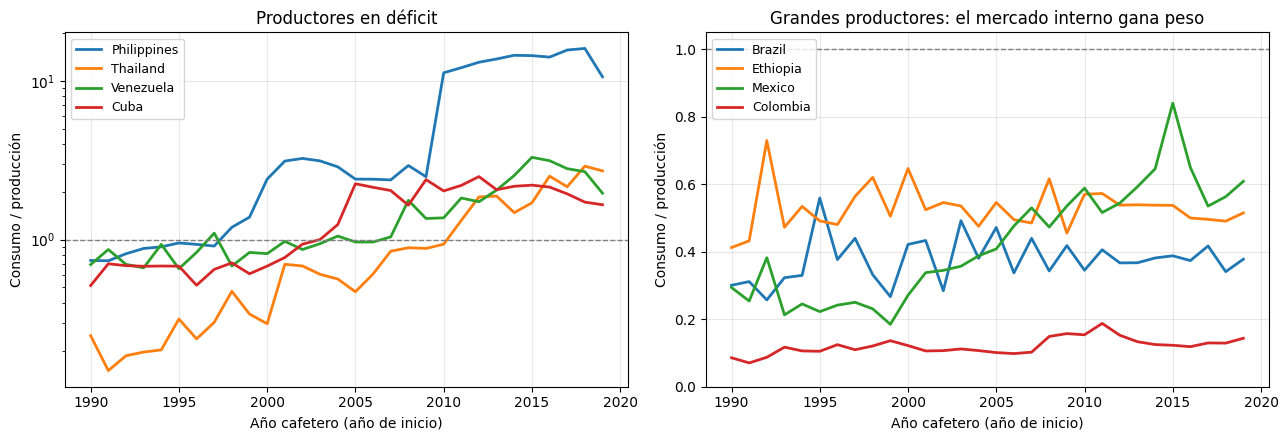

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for pais, color in [("Philippines", "#A3243B"), ("Thailand", "#9A6A12"), ("Venezuela", "#3F7A4A"), ("Cuba", "#2D4F7C")]:
    serie = balance[balance["country"] == pais]
    axes[0].plot(serie["anio_inicio"], serie["ratio_consumo_produccion"], label=pais, linewidth=2)
for pais, color in [("Brazil", "#3F7A4A"), ("Ethiopia", "#A3243B"), ("Mexico", "#9A6A12"), ("Colombia", "#2D4F7C")]:
    serie = balance[balance["country"] == pais]
    axes[1].plot(serie["anio_inicio"], serie["ratio_consumo_produccion"], label=pais, linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("Productores en déficit")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Grandes productores: el mercado interno gana peso")
for ax in axes:
    ax.axhline(1, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("Año cafetero (año de inicio)")
    ax.set_ylabel("Consumo / producción")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3.9 Cierre de la fase

| Decisión | Origen | Efecto en el modelado |
|---|---|---|
| Consumo a sacos (`kg / 60`) y producción a sacos (`t / 0,06`) | Hallazgo de unidades (2.2) | Ambas series comparables |
| `AAAA` de producción = año cafetero `(AAAA−1)/AA` | Verificación con la cifra de Brasil | Balance alineado en el tiempo |
| Ceros convertidos en faltantes | Patrones de ceros (2.4) | Sin falsos déficits ni promedios sesgados |
| Tipo de café tomado del archivo de consumo | Paraguay con `0` en producción | Segmentación por producto confiable |
| Producción de Filipinas usada desde 2010/11 | Quiebre de serie | Tendencia sin el salto artificial |
| Países segmentados en modelable, consumo plano y excluido | Series con escalones (2.6) | El torneo de modelos corre solo donde hay señal |

La fase 4 toma `coffee_balance_long.parquet`, proyecta consumo y producción por país a 3 años cafeteros y deriva el excedente
y el ratio proyectados, eligiendo el modelo por serie con backtesting de origen móvil.